In [55]:
%load_ext autoreload
%autoreload 2


import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import pprint
# import pyspark
from pyspark.sql import SparkSession   #Try new way to import Spark
import pyspark.sql.functions as F

from pyspark.sql.functions import col
from pyspark.sql.types import StringType, IntegerType, FloatType, DateType

import utils.data_processing_bronze_table
import utils.data_processing_silver_table
import utils.data_processing_gold_table
import test_datamart.python_script.data_processing_bronze as bronze_processing
import test_datamart.python_script.data_processing_silver as silver_processing
import test_datamart.python_script.data_processing_gold as gold_processing


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
#Initialize Spark Session

spark = SparkSession.builder \
    .appName("dev_test") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/21 06:23:49 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


### Set up config

In [3]:
# Set up config
start_date_str = "2023-01-01"
end_date_str = "2024-12-01"
snapshot_date_str = "2023-01-01"



In [4]:
# Generate a list of dates to process
def generate_first_of_month_dates(start_date_str, end_date_str):
    #convert the date string into datetime format
    start_date = datetime.strptime(start_date_str, "%Y-%m-%d")
    end_date = datetime.strptime(end_date_str, "%Y-%m-%d")

    # A list of first of month dates
    first_of_month_dates = []

    # Set current date = start date
    current_date = datetime(start_date.year, start_date.month, 1)

    # Loop until current date is less than or equal to end date
    while current_date <= end_date:
        first_of_month_dates.append(current_date.strftime("%Y-%m-%d"))

        if current_date.month == 12: 
            current_date = datetime(current_date.year + 1, 1, 1)

        else: 
            current_date = datetime(current_date.year, current_date.month + 1, 1)

    return first_of_month_dates


date_list = generate_first_of_month_dates (start_date_str, end_date_str)
date_list


['2023-01-01',
 '2023-02-01',
 '2023-03-01',
 '2023-04-01',
 '2023-05-01',
 '2023-06-01',
 '2023-07-01',
 '2023-08-01',
 '2023-09-01',
 '2023-10-01',
 '2023-11-01',
 '2023-12-01',
 '2024-01-01',
 '2024-02-01',
 '2024-03-01',
 '2024-04-01',
 '2024-05-01',
 '2024-06-01',
 '2024-07-01',
 '2024-08-01',
 '2024-09-01',
 '2024-10-01',
 '2024-11-01',
 '2024-12-01']

### Build Bronze Table

In [5]:
# Create a bronze datalake
bronze_directory =  "test_datamart/bronze/lms/"

if not os.path.exists(bronze_directory):
    os.makedirs(bronze_directory)

In [6]:
# Create a folder to store python script for data processing
if not os.path.exists("test_datamart/python_script"):
    os.makedirs("test_datamart/python_script")

In [8]:
# Load data to bronze datalake
for snapshot_date in date_list:
    bronze_processing.process_bronze_table(snapshot_date, bronze_directory, spark)


2023-01-01Number of records:  530
Saved to: test_datamart/bronze/lms/bronze_loan_daily_2023_01_01.csv
2023-02-01Number of records:  1031
Saved to: test_datamart/bronze/lms/bronze_loan_daily_2023_02_01.csv
2023-03-01Number of records:  1537
Saved to: test_datamart/bronze/lms/bronze_loan_daily_2023_03_01.csv
2023-04-01Number of records:  2047
Saved to: test_datamart/bronze/lms/bronze_loan_daily_2023_04_01.csv
2023-05-01Number of records:  2568
Saved to: test_datamart/bronze/lms/bronze_loan_daily_2023_05_01.csv
2023-06-01Number of records:  3085
Saved to: test_datamart/bronze/lms/bronze_loan_daily_2023_06_01.csv
2023-07-01Number of records:  3556
Saved to: test_datamart/bronze/lms/bronze_loan_daily_2023_07_01.csv
2023-08-01Number of records:  4037
Saved to: test_datamart/bronze/lms/bronze_loan_daily_2023_08_01.csv
2023-09-01Number of records:  4491
Saved to: test_datamart/bronze/lms/bronze_loan_daily_2023_09_01.csv
2023-10-01Number of records:  4978
Saved to: test_datamart/bronze/lms/bron

### Build silver table

In [7]:
# Create Silver datalake
silver_directory = "test_datamart/silver/lms/"

if not os.path.exists(silver_directory):
    os.makedirs(silver_directory)

In [9]:
# Load data to silver datalake
for snapshot_date in date_list:
    silver_processing.process_silver_table(snapshot_date, bronze_directory, silver_directory, spark)

Saved to:  test_datamart/silver/lms/silver_loan_daily_2023_01_01.parquet
Saved to:  test_datamart/silver/lms/silver_loan_daily_2023_02_01.parquet


Saved to:  test_datamart/silver/lms/silver_loan_daily_2023_03_01.parquet


Saved to:  test_datamart/silver/lms/silver_loan_daily_2023_04_01.parquet
Saved to:  test_datamart/silver/lms/silver_loan_daily_2023_05_01.parquet


Saved to:  test_datamart/silver/lms/silver_loan_daily_2023_06_01.parquet
Saved to:  test_datamart/silver/lms/silver_loan_daily_2023_07_01.parquet
Saved to:  test_datamart/silver/lms/silver_loan_daily_2023_08_01.parquet


Saved to:  test_datamart/silver/lms/silver_loan_daily_2023_09_01.parquet
Saved to:  test_datamart/silver/lms/silver_loan_daily_2023_10_01.parquet
Saved to:  test_datamart/silver/lms/silver_loan_daily_2023_11_01.parquet
Saved to:  test_datamart/silver/lms/silver_loan_daily_2023_12_01.parquet


Saved to:  test_datamart/silver/lms/silver_loan_daily_2024_01_01.parquet
Saved to:  test_datamart/silver/lms/silver_loan_daily_2024_02_01.parquet


Saved to:  test_datamart/silver/lms/silver_loan_daily_2024_03_01.parquet
Saved to:  test_datamart/silver/lms/silver_loan_daily_2024_04_01.parquet
Saved to:  test_datamart/silver/lms/silver_loan_daily_2024_05_01.parquet
Saved to:  test_datamart/silver/lms/silver_loan_daily_2024_06_01.parquet


Saved to:  test_datamart/silver/lms/silver_loan_daily_2024_07_01.parquet
Saved to:  test_datamart/silver/lms/silver_loan_daily_2024_08_01.parquet
Saved to:  test_datamart/silver/lms/silver_loan_daily_2024_09_01.parquet
Saved to:  test_datamart/silver/lms/silver_loan_daily_2024_10_01.parquet
Saved to:  test_datamart/silver/lms/silver_loan_daily_2024_11_01.parquet
Saved to:  test_datamart/silver/lms/silver_loan_daily_2024_12_01.parquet


In [10]:
df = silver_processing.process_silver_table(snapshot_date, bronze_directory, silver_directory, spark)
df.show(10)

Saved to:  test_datamart/silver/lms/silver_loan_daily_2024_12_01.parquet
+--------------------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+---+-------------------+-----------------+---+
|             loan_id|customer_id|loan_start_date|tenure|installment_num|loan_amt|due_amt|paid_amt|overdue_amt|balance|snapshot_date|mob|missed_installments|first_missed_date|dpd|
+--------------------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+---+-------------------+-----------------+---+
|CUS_0x100b_2024_0...| CUS_0x100b|     2024-03-01|    10|              9| 10000.0| 1000.0|  1000.0|        0.0| 1000.0|   2024-12-01|  9|                  0|             NULL|  0|
|CUS_0x102e_2024_0...| CUS_0x102e|     2024-04-01|    10|              8| 10000.0| 1000.0|     0.0|     6000.0| 8000.0|   2024-12-01|  8|                  6|       2024-06-01|183|
|CUS_0x1038_2024_1...| CUS_

In [11]:
df2 = df.toPandas()
df2

,loan_id,customer_id,loan_start_date,tenure,installment_num,loan_amt,due_amt,paid_amt,overdue_amt,balance,snapshot_date,mob,missed_installments,first_missed_date,dpd
0,CUS_0x100b_2024_03_01,CUS_0x100b,2024-03-01,10,9,10000.0,1000.0,1000.0,0.0,1000.0,2024-12-01,9,0,None,0
1,CUS_0x102e_2024_04_01,CUS_0x102e,2024-04-01,10,8,10000.0,1000.0,0.0,6000.0,8000.0,2024-12-01,8,6,2024-06-01,183
2,CUS_0x1038_2024_10_01,CUS_0x1038,2024-10-01,10,2,10000.0,1000.0,1000.0,0.0,8000.0,2024-12-01,2,0,None,0
3,CUS_0x103e_2024_12_01,CUS_0x103e,2024-12-01,10,0,10000.0,0.0,0.0,0.0,10000.0,2024-12-01,0,0,None,0
4,CUS_0x1048_2024_02_01,CUS_0x1048,2024-02-01,10,10,10000.0,1000.0,0.0,9000.0,9000.0,2024-12-01,10,9,2024-03-01,275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5526,CUS_0xfe3_2024_04_01,CUS_0xfe3,2024-04-01,10,8,10000.0,1000.0,1000.0,0.0,2000.0,2024-12-01,8,0,None,0
5527,CUS_0xff3_2024_06_01,CUS_0xff3,2024-06-01,10,6,10000.0,1000.0,1000.0,0.0,4000.0,2024-12-01,6,0,None,0
5528,CUS_0xff4_2024_12_01,CUS_0xff4,2024-12-01,10,0,10000.0,0.0,0.0,0.0,10000.0,2024-12-01,0,0,None,0
5529,CUS_0xff6_2024_10_01,CUS_0xff6,2024-10-01,10,2,10000.0,1000.0,1000.0,0.0,8000.0,2024-12-01,2,0,None,0


### EDA on Credit Label

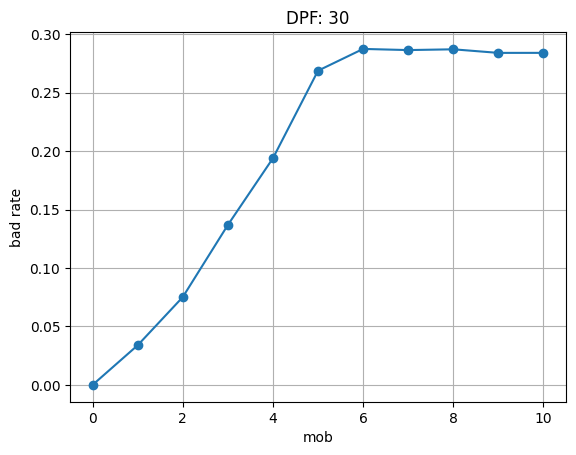

In [17]:
# Set dpd label definition
dpd = 30

file_path = silver_directory
file_list = [file_path + os.path.basename(f) for f in glob.glob(os.path.join(file_path, "*.parquet"))]

# Read all files into a dataframe
df = spark.read.option("header", "true").parquet(*file_list)

# Filter dataframe to include only loans before 01-12-2024 (completed loans)
df = df.filter(col("snapshot_date") < datetime.strptime("2024-12-01", "%Y-%m-%d"))

# Create dpd flag if dpd > dpd label
df = df.withColumn("dpd_flag", F.when(col("dpd") > dpd, 1).otherwise(0))

# Convert Pyspark dataframe to Panda dataframe for visualization
pdf = df.toPandas()

# Group by mob flag and calculate the actual bad rate
grouped = pdf.groupby("mob")["dpd_flag"].mean()
# Sort by mob
grouped = grouped.sort_index()

#Plot the line chart of bad rate by mob
grouped.plot(kind = "line", marker = "o")
plt.title("DPF: " + str(dpd))
plt.xlabel("mob")
plt.ylabel("bad rate")
plt.grid(True)
plt.show()

# Create dataframe to include the last installment period only 
actual_bad_df = df.filter(col("installment_num") == 10)



### Build Gold Tables

In [102]:
# Create gold datalake
gold_directory = "test_datamart/gold/lms/"

if not os.path.exists(gold_directory):
    os.makedirs(gold_directory)

In [105]:
# backfill data to gold datalake
for snapshot_date in date_list:
    gold_processing.process_gold_table(snapshot_date, silver_directory, gold_directory, spark, dpd = 30, mob = 6)

Saved to:  test_datamart/gold/lms/gold_label_2023_01_01.parquet
Saved to:  test_datamart/gold/lms/gold_label_2023_02_01.parquet


Saved to:  test_datamart/gold/lms/gold_label_2023_03_01.parquet
Saved to:  test_datamart/gold/lms/gold_label_2023_04_01.parquet
Saved to:  test_datamart/gold/lms/gold_label_2023_05_01.parquet
Saved to:  test_datamart/gold/lms/gold_label_2023_06_01.parquet
Saved to:  test_datamart/gold/lms/gold_label_2023_07_01.parquet
Saved to:  test_datamart/gold/lms/gold_label_2023_08_01.parquet
Saved to:  test_datamart/gold/lms/gold_label_2023_09_01.parquet
Saved to:  test_datamart/gold/lms/gold_label_2023_10_01.parquet
Saved to:  test_datamart/gold/lms/gold_label_2023_11_01.parquet
Saved to:  test_datamart/gold/lms/gold_label_2023_12_01.parquet
Saved to:  test_datamart/gold/lms/gold_label_2024_01_01.parquet


Saved to:  test_datamart/gold/lms/gold_label_2024_02_01.parquet
Saved to:  test_datamart/gold/lms/gold_label_2024_03_01.parquet
Saved to:  test_datamart/gold/lms/gold_label_2024_04_01.parquet
Saved to:  test_datamart/gold/lms/gold_label_2024_05_01.parquet
Saved to:  test_datamart/gold/lms/gold_label_2024_06_01.parquet


Saved to:  test_datamart/gold/lms/gold_label_2024_07_01.parquet
Saved to:  test_datamart/gold/lms/gold_label_2024_08_01.parquet
Saved to:  test_datamart/gold/lms/gold_label_2024_09_01.parquet
Saved to:  test_datamart/gold/lms/gold_label_2024_10_01.parquet


Saved to:  test_datamart/gold/lms/gold_label_2024_11_01.parquet
Saved to:  test_datamart/gold/lms/gold_label_2024_12_01.parquet


In [62]:
gold_processing.process_gold_table(snapshot_date, silver_directory, gold_directory, spark, dpd = 30, mob = 6).dtypes


Saved to:  test_datamart/gold/lmsgold_label_2024_12_01.parquet


[('loan_id', 'string'),
 ('customer_id', 'string'),
 ('label', 'int'),
 ('label_def', 'string'),
 ('snapshot_date', 'date')]

### Inspect label store

In [106]:
file_path = gold_directory
file_list = [file_path + os.path.basename(f) for f in glob.glob(os.path.join(file_path, "*.parquet"))]

df = spark.read.option("header", "true").parquet(*file_list)
print("row count: ", df.count())
df.show()

row count:  8974
+--------------------+-----------+-----+----------+-------------+
|             loan_id|customer_id|label| label_def|snapshot_date|
+--------------------+-----------+-----+----------+-------------+
|CUS_0x1037_2023_0...| CUS_0x1037|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1069_2023_0...| CUS_0x1069|    0|30dpd_6mob|   2023-07-01|
|CUS_0x114a_2023_0...| CUS_0x114a|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1184_2023_0...| CUS_0x1184|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1297_2023_0...| CUS_0x1297|    1|30dpd_6mob|   2023-07-01|
|CUS_0x12fb_2023_0...| CUS_0x12fb|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1325_2023_0...| CUS_0x1325|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1341_2023_0...| CUS_0x1341|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1375_2023_0...| CUS_0x1375|    1|30dpd_6mob|   2023-07-01|
|CUS_0x13a8_2023_0...| CUS_0x13a8|    0|30dpd_6mob|   2023-07-01|
|CUS_0x13ef_2023_0...| CUS_0x13ef|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1440_2023_0...| CUS_0x1440|    0|30dpd_6mob|   2023-

In [107]:
df.printSchema()

root
 |-- loan_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- label: integer (nullable = true)
 |-- label_def: string (nullable = true)
 |-- snapshot_date: date (nullable = true)

